# **Directed percolation in Rust-Python**

Demo simulation of directed percolation on a 3d lattice.

<hr>

## Preliminaries

In [1]:
from essentials import *
dprs.__version__

'2026.4.4'

<hr>

## Parameters

In [2]:
class Parameters:
    growth_model_choice = GrowthModelChoice.SimplifiedDomanyKinzel
    dim = Dimension.D3
    n_x: int = 300
    n_y: int = 300
    n_z: int = 300
    p_1: float = 0.0482745
    p_2: float = 0
    n_iterations: int = 1000
    sample_period: int  = 0
    initial_condition = InitialCondition.Randomized
    # initial_condition = InitialCondition.CentralSeed
    p_initial: float = 0.99
    random_seed: int = 1
    topology_x = Topology.Periodic
    topology_y = Topology.Periodic
    topology_z = Topology.Periodic
    bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_y = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_z = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_y = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_z = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    do_edge_buffering: bool = True
    processing = Processing.Parallel
    n_threads: int = 16
parameters = Parameters()
# Just in case we forget to update sample_period to match n_iterations
if parameters.sample_period > parameters.n_iterations:
    parameters.sample_period = parameters.n_iterations

In [3]:
parameters.initial_condition

InitialCondition.Randomized

<hr>

## Simulation

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [4]:
n_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float

In [5]:
(n_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)


Growth model:  SimplifiedDomanyKinzel
Dimension:     D3
Grid shape:    (300, 300, 300)
Prob. p_1:     0.0482745
Prob. p_2:     0
Iterations:    1000
Sample period: 0
Initial cond.: Randomized
Initial prob.: 0.99
Random seed:   1
Topology x:    Periodic
Topology y:    Periodic
Topology z:    Periodic
Axis BCs x:    (Floating, Floating)
Axis BCs y:    (Floating, Floating)
Axis BCs z:    (Floating, Floating)
BC values x:   (Occupied, Occupied)
BC values y:   (Occupied, Occupied)
BC values z:   (Occupied, Occupied)
Edge buffer:   true
Processing:    Parallel
Num. threads:  16


Simulation run time (parallel): 19.114s


In [6]:
print(f"Total number of lattice time slices = {n_lattices}\n")

Total number of lattice time slices = 0



<hr>

## Post-processing

The function `sim.dk` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all of them concatenated into one long 1d list.

We convert this long list into a 3+1d numpy array, with the last index being the lattice slice number. Care must be taken to reshape by the grid dimensions in the correct order: the fastest index in the list is the x coordinate, etc., so the reshaping parameters need to be given in reverse order `(n_lattices, z, y, x)`.

In [7]:
lattices: NDArray
if n_lattices>0:
    lattices = np.array(raw_lattices, dtype=np.bool,).reshape(
        n_lattices, parameters.n_z, parameters.n_y, parameters.n_x,
    ).T
else:
    lattices = np.zeros((0,))
lattices.shape

(0,)

Tracking data, which for now is the vector pair (t; mean ρ):

In [8]:
pruned_tracking = []
for data in raw_tracking:
    if len(data)>0:
        pruned_tracking.append(data)

In [9]:
tracking: NDArray = np.array(pruned_tracking, dtype=np.float64,) 
tracking.shape

(4, 1001)

<hr>

## Visualization

### Prep

In [10]:
viz = Viz(dpi=100)
i_slice: int
name: str

In [11]:
z_slice: int = parameters.n_z//2
image_lattice = partial(
    viz.image_lattice,
    lattices=lattices, 
    p=parameters, 
    x=(parameters.n_x//10) * 1,
    y=(parameters.n_y//10) * 1,
    z=z_slice,
    fig_size=(6, 4,),
)

### Slices

Visualize the initial lattice:

In [12]:
if n_lattices>0:
    i_slice = 0
    name = make_name(parameters, "lattice", i_slice, )
    print(name)
    image_lattice(
        name=name, 
        title=make_title(parameters, i_slice, z_slice), 
        i_lattice=i_slice,
    )
    plt.show()

Visualize the final lattice:

In [13]:
if n_lattices>=1:
    i_slice = (n_lattices-1)
    name = make_name(parameters, "lattice", i_slice,)
    print(name)
    image_lattice(
        name=name, 
        title=make_title(parameters, i_slice, z_slice), 
        i_lattice=i_slice,
    )
    plt.show()

### History

See Henkel et al (2008), tables 4.1 and 4.3: the decay rate of the mean order parameter (mean occupancy) $\overline\rho$ should decay with time as
$$
    \rho(t) \sim t^{-\delta}
$$
where in $d=3$ we should find $\delta \approx 0.7324$. If that's what we're seeing, there's a long "burn-in" phase. It appears we're a bit off the ideal value: (1) because there is a finite lattice-size bias; and (2) because we need to extremely precise about choosing $p=p_c$. 

Here I have heuristically tuned $p$ to
$$
    p = p_c? = \,\,0.0482745
$$
which is rather far off any traditional critical DP probability $p_c$, probably because of the 27-cell neighborhood live/die dependency.

ρmean_p0p0482745_s1_nx300_ny300_nz300


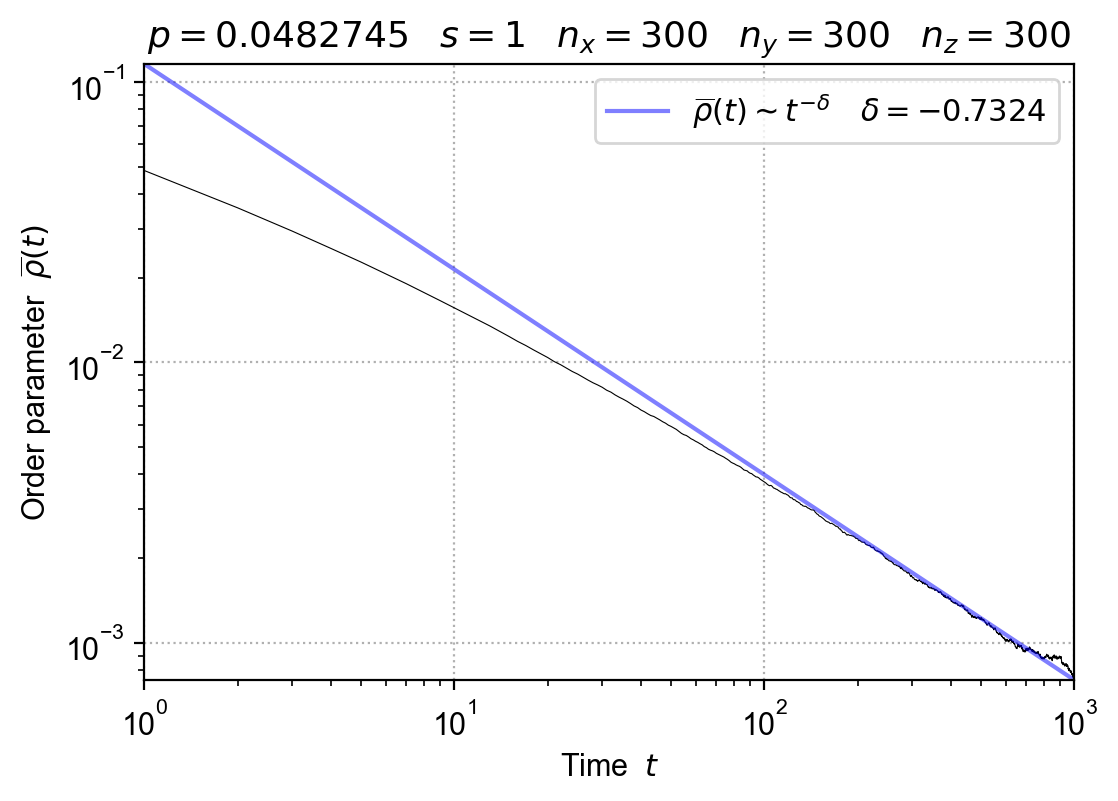

In [14]:
δ = 0.7324
scale = 0.116

name = make_name(parameters, "ρmean", None, )
print(name)
viz.plot_lattice_statistic(
    name,
    make_title(parameters, None),
    tracking,
    labels=(
        "Order parameter  $\\widebar{\\rho}(t)$", 
        "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        "${\\delta}$",
    ),
    index=2,
    exponent=-δ, 
    scale=scale,
    i_offset=1,
    do_ref_curve=True,
)
plt.show()

In [15]:
i_offset: int = parameters.n_iterations//3
t: NDArray = tracking[0][i_offset:]
ρ_mean: NDArray = tracking[1][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))

print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")

Estimated t-decay exponent:  δ = -0.636


<hr>

## Export

In [16]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "dp3d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/dp3d'